In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import scarf

scarf.configure_output(level="ERROR", progress=False)
repository = scarf.cytebase.connect("scarf_docs")
mount_directory = TemporaryDirectory()
staged_dataset = repository.download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination=mount_directory.name,
    zarr=True,
)
source_path = staged_dataset / 'data.zarr'
target_path = Path(mount_directory.name) / 'analysis.zarr'
{"count source": str(source_path), "analysis target": str(target_path)}

Downloading bucket files: 56215324 / 56215324 complete

Downloading bytes: 56215324 / 56215324 complete

{'count source': '/var/folders/v3/4132lx197d702pl_10s5r8b80000gn/T/tmp66ltra68/tenx_5K_pbmc_rnaseq/data.zarr',
 'analysis target': '/var/folders/v3/4132lx197d702pl_10s5r8b80000gn/T/tmp66ltra68/analysis.zarr'}

In [2]:
mounted = scarf.mount_datastore(
    str(source_path),
    at=str(target_path),
    default_assay='RNA',
    nthreads=4,
)
mounted

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

In [3]:
mounted_run = mounted.pipeline.run(label="mounted_analysis")
mounted_run.status

'completed'

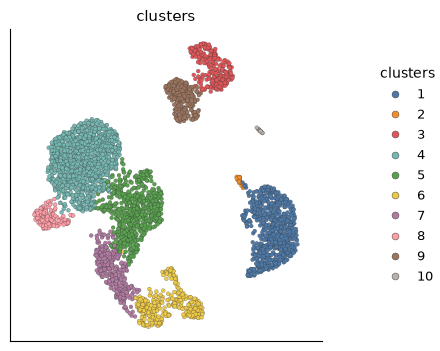

In [4]:
mounted.plots.embedding(run=mounted_run, color_by="clusters")

In [5]:
reopened = scarf.DataStore(str(target_path), nthreads=4)
reopened_run = reopened.pipeline.open(run_id=mounted_run.run_id)
reopened_run.status

'completed'